# Predictor de Demanda de Cursos - USFQ

Este notebook reproduce el pipeline de predicción de demanda de cursos de la
Universidad San Francisco de Quito (USFQ). Combina el módulo híbrido
(media histórica + flujo DAG + planificación en plataforma) con un modelo
**Gradient Boosting Regressor** opcional.

**Estructura del notebook:**

1. Parámetros de ejecución
2. Imports y configuración global
3. Exportación de datos (Supabase)
4. Calendario académico
5. Grafo de mallas curriculares
6. Estadísticas históricas
7. Propagación de demanda (DAG)
8. Calibración de tasas de transición
9. Fórmula híbrida de demanda
10. Feature engineering completo
11. Entrenamiento GBR
12. Aplicación del modelo
13. Backtesting (opcional)
14. Exportación y resultados
15. Resumen final

## Parámetros de ejecución

Las siguientes variables controlan qué etapas del pipeline se ejecutan.
Cambie `FACULTY` para filtrar por facultad (ej. `"CMP"`, `"MAC"`) o déjelo
en `None` para procesar todas las facultades.

In [4]:
# --- Parametros --------------------------------------------------------
FACULTY: str | None = None         # None = todas las facultades

def normalize_faculty(value: str | None) -> str | None:
    if value is None:
        return None
    cleaned = str(value).strip()
    if cleaned.lower() in {"", "none", "null", "todas", "all"}:
        return None
    return cleaned

FACULTY_FILTER = normalize_faculty(FACULTY)
SKIP_EXPORT: bool = True            # True = usa datos cacheados en predictor/output/
SKIP_CALIBRATION: bool = False      # False = recalibrar tasas de transicion
SKIP_BACKTEST: bool = True          # True = saltar backtesting (es lento)
SKIP_GBR: bool = False              # False = entrenar GBR si hay datos suficientes
PREFER_GBR: bool = True             # True = usar estimados GBR como primarios
FORCE_RECOMPUTE: bool = False       # True = re-ejecutar todo aunque haya cache
# -------------------------------------------------------------------------

## Imports y configuración global

Importamos todas las librerías necesarias y configuramos rutas relativas
al repositorio. Se utiliza `dotenv` para variables de entorno de Supabase.

In [5]:
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [6]:
import json
import os
import pickle
import re
import sys
import warnings
from collections import defaultdict
from dataclasses import dataclass, field
from datetime import datetime, timezone
from enum import Enum
from pathlib import Path
from typing import Iterator, Literal

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import requests
from dotenv import load_dotenv
from sklearn.ensemble import GradientBoostingRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
get_ipython().run_line_magic('matplotlib', 'inline')

NOTEBOOK_DIR = Path.cwd().resolve()
REPO_ROOT = NOTEBOOK_DIR.parent
PREDICTOR_DIR = REPO_ROOT / "predictor"
OUTPUT_DIR = PREDICTOR_DIR / "output"
CURRICULA_DIR = REPO_ROOT / "frontend" / "src" / "data"
PUBLIC_DASHBOARD_DIR = REPO_ROOT / "frontend" / "public" / "data"
PERIODS_JSON = REPO_ROOT / "offer-scraper" / "periods.json"

sys.path.insert(0, str(PREDICTOR_DIR))

load_dotenv(PREDICTOR_DIR / ".env")

SUPABASE_URL = os.environ.get("SUPABASE_URL", "")
SUPABASE_KEY = os.environ.get("SUPABASE_KEY", os.environ.get("SUPABASE_SERVICE_KEY", ""))

OUTPUT_DIR.mkdir(exist_ok=True)
PUBLIC_DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)

print("Configuracion cargada")
print(f"  REPO_ROOT = {REPO_ROOT}")
print(f"  OUTPUT_DIR = {OUTPUT_DIR}")
print(f"  SUPABASE_URL = {'***' if SUPABASE_URL else 'no configurada'}")

Configuracion cargada
  REPO_ROOT = /Users/joshuareinoso/Documents/GitHub/malla-curricular-interactiva
  OUTPUT_DIR = /Users/joshuareinoso/Documents/GitHub/malla-curricular-interactiva/predictor/output
  SUPABASE_URL = ***


## Constantes globales

Estas constantes están alineadas con el frontend
(`frontend/lib/demandPrediction.ts` y `curriculumGraph.ts`).

In [7]:
STUDENTS_PER_SECTION = 25
MIN_STABLE_ENROLLMENT = 8
MAX_DAG_HOPS = 5
MIN_DAG_FLOW = 0.25
P_SEQUENTIAL = 0.8
P_SAME_AREA = 0.5
P_OTHER = 0.25
W_EST_NEXT = 0.45
W_AVG_STUDENTS = 0.15
W_INFLOW_HIST = 0.25
W_INFLOW_CURS = 0.10
W_PLANNED = 0.05
W_SEC_EST = 0.35
W_SEC_AVG = 0.25
W_SEC_FROM_EST = 0.25
W_SEC_INFLOW_HIST = 0.10
W_SEC_INFLOW_CURS = 0.05
TRANSITION_SHRINKAGE_ALPHA = 75.0
TRANSITION_RATE_MIN = 0.05
TRANSITION_RATE_MAX = 0.95

TRANSITION_RATES_JSON = OUTPUT_DIR / "transition_rates.json"
PUBLIC_TRANSITION_RATES_JSON = PUBLIC_DASHBOARD_DIR / "transition_rates.json"
PUBLIC_DASHBOARD_JSON = PUBLIC_DASHBOARD_DIR / "predictor-dashboard.json"

print("Constantes cargadas")

Constantes cargadas


## 1. Exportación de datos desde Supabase

Se descargan las tablas `user_progress`, `course_offer_history` y `course_offer`
desde Supabase via REST API. Si `SKIP_EXPORT=True` se usan los archivos JSON
cacheados en `predictor/output/`.

In [8]:
def fetch_table(table: str, select: str = "*") -> list[dict]:
    if not SUPABASE_URL or not SUPABASE_KEY:
        raise RuntimeError("SUPABASE_URL and SUPABASE_KEY must be set")
    rows: list[dict] = []
    offset = 0
    page_size = 1000
    while True:
        headers = {
            "apikey": SUPABASE_KEY,
            "Authorization": f"Bearer {SUPABASE_KEY}",
        }
        resp = requests.get(
            f"{SUPABASE_URL}/rest/v1/{table}",
            headers=headers,
            params={"select": select, "offset": offset, "limit": page_size},
            timeout=60,
        )
        resp.raise_for_status()
        batch = resp.json()
        if not batch:
            break
        rows.extend(batch)
        if len(batch) < page_size:
            break
        offset += page_size
    return rows


def fetch_offer_metadata_() -> dict:
    if not SUPABASE_URL or not SUPABASE_KEY:
        return {}
    headers = {
        "apikey": SUPABASE_KEY,
        "Authorization": f"Bearer {SUPABASE_KEY}",
    }
    resp = requests.get(
        f"{SUPABASE_URL}/rest/v1/offer_metadata",
        headers=headers,
        params={"select": "*", "id": "eq.1"},
        timeout=30,
    )
    resp.raise_for_status()
    rows = resp.json()
    return rows[0] if rows else {}


def export_all(out_dir: Path | None = None) -> dict[str, Path]:
    dest = out_dir or OUTPUT_DIR
    dest.mkdir(exist_ok=True)
    paths = {}
    for table in ("user_progress", "course_offer_history", "course_offer"):
        data = fetch_table(table)
        path = dest / f"{table}.json"
        with open(path, "w", encoding="utf-8") as f:
            json.dump(data, f, indent=2, default=str)
        paths[table] = path
        print(f"Exportados {len(data)} registros -> {path}")
    meta = fetch_offer_metadata_()
    meta_path = dest / "offer_metadata.json"
    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2, default=str)
    paths["offer_metadata"] = meta_path
    print(f"Exportado offer_metadata -> {meta_path}")
    return paths


def load_offer_metadata(path: Path | None = None) -> dict:
    p = path or OUTPUT_DIR / "offer_metadata.json"
    if not p.exists():
        return {}
    with open(p, encoding="utf-8") as f:
        return json.load(f)

In [9]:
if not SKIP_EXPORT or FORCE_RECOMPUTE:
    paths = export_all()
else:
    print("Usando datos cacheados en predictor/output/")
    for fname in ("user_progress.json", "course_offer_history.json", "course_offer.json", "offer_metadata.json"):
        p = OUTPUT_DIR / fname
        if p.exists():
            print(f"  {fname} ({p.stat().st_size / 1024:.0f} KB)")
        else:
            print(f"  [FALTA] {fname}")

meta = load_offer_metadata()
print(f"Periodo actual: {meta.get('current_period_code', '?')}")
print(f"Ultimo scrapeo: {meta.get('last_scraped_at', '?')}")

Usando datos cacheados en predictor/output/
  user_progress.json (0 KB)
  course_offer_history.json (9639 KB)
  course_offer.json (2082 KB)
  offer_metadata.json (0 KB)
Periodo actual: 202610
Ultimo scrapeo: 2026-06-27T11:57:09.888439+00:00


## 2. Calendario académico

El `AcademicCalendar` administra los períodos académicos de USFQ:
- **regular_10**: primer semestre (ej. `202510`)
- **regular_20**: segundo semestre (ej. `202520`)
- **summer**: verano (ej. `202530`)
- **medical_year**: períodos médicos especiales

El calendario se carga desde `offer-scraper/periods.json`.

In [10]:
PeriodKind = Literal["regular_10", "regular_20", "summer", "medical_year", "unknown"]


class PeriodInfo:
    __slots__ = ("code", "label", "kind", "year", "suffix")

    def __init__(self, code: str, label: str = "") -> None:
        self.code = str(code)
        self.label = label or self.code
        self.suffix = self.code[-2:] if len(self.code) >= 2 else ""
        self.year = int(self.code[:4]) if len(self.code) >= 4 and self.code[:4].isdigit() else 0
        self.kind = classify_period_kind(self.code)

    def __repr__(self) -> str:
        return f"PeriodInfo({self.code!r}, {self.kind})"


def classify_period_kind(period_code: str) -> PeriodKind:
    code = str(period_code)
    if len(code) < 2:
        return "unknown"
    suffix = code[-2:]
    if suffix == "30":
        return "summer"
    if suffix in ("10", "20"):
        return "regular_10" if suffix == "10" else "regular_20"
    if suffix in ("08", "13", "23", "03"):
        return "medical_year"
    return "unknown"


def is_regular(kind: PeriodKind) -> bool:
    return kind in ("regular_10", "regular_20")


def is_summer_period(period_code: str) -> bool:
    return classify_period_kind(period_code) == "summer"


def is_medical_period(period_code: str) -> bool:
    return classify_period_kind(period_code) == "medical_year"


def load_period_catalog(path: Path | None = None) -> list[PeriodInfo]:
    p = path or PERIODS_JSON
    if not p.exists():
        return []
    with open(p, encoding="utf-8") as f:
        raw = json.load(f)
    return [PeriodInfo(row["code"], row.get("label", "")) for row in raw]


class AcademicCalendar:
    def __init__(self, catalog: list[PeriodInfo]) -> None:
        self._by_code: dict[str, PeriodInfo] = {p.code: p for p in catalog}
        self._chrono: list[PeriodInfo] = sorted(catalog, key=lambda p: p.code)
        self._regular: list[PeriodInfo] = [p for p in self._chrono if is_regular(p.kind)]
        self._summers: list[PeriodInfo] = [p for p in self._chrono if p.kind == "summer"]

    def get(self, code: str) -> PeriodInfo | None:
        return self._by_code.get(code)

    def all_codes(self) -> list[str]:
        return [p.code for p in self._chrono]

    def regular_codes(self) -> list[str]:
        return [p.code for p in self._regular]

    def codes_before(self, target_code: str, *, include_target: bool = False) -> list[str]:
        codes = self.all_codes()
        if target_code not in self._by_code:
            return codes
        idx = codes.index(target_code)
        end = idx + 1 if include_target else idx
        return codes[:end]

    def next_regular(self, from_code: str) -> str | None:
        codes = self.all_codes()
        if from_code not in self._by_code:
            return self._regular[-1].code if self._regular else None
        start = codes.index(from_code) + 1
        for code in codes[start:]:
            if is_regular(self._by_code[code].kind):
                return code
        return None

    def advance_regular(self, from_code: str, semester_delta: int) -> str | None:
        if semester_delta <= 0:
            return from_code if from_code in self._by_code else None
        current = from_code
        for _ in range(semester_delta):
            nxt = self.next_regular(current)
            if not nxt:
                return None
            current = nxt
        return current

    def summer_before_regular(self, regular_code: str) -> str | None:
        codes = self.all_codes()
        if regular_code not in self._by_code:
            return None
        info = self._by_code[regular_code]
        if info.kind != "regular_10":
            return None
        idx = codes.index(regular_code)
        for i in range(idx - 1, -1, -1):
            if self._by_code[codes[i]].kind == "summer":
                return codes[i]
        return None

    def infer_target_period(self, current_period_code: str | None) -> tuple[str, str]:
        if not self._chrono:
            return ("", "")
        if not current_period_code or current_period_code not in self._by_code:
            last_reg = self._regular[-1] if self._regular else self._chrono[-1]
            nxt = self.next_regular(last_reg.code) or last_reg.code
            tgt = self._by_code.get(nxt)
            return (nxt, tgt.label if tgt else nxt)
        kind = self._by_code[current_period_code].kind
        if kind == "summer":
            nxt = self.next_regular(current_period_code)
        elif is_regular(kind):
            nxt = self.next_regular(current_period_code)
        else:
            nxt = self.next_regular(current_period_code)
        if not nxt:
            nxt = self._regular[-1].code if self._regular else current_period_code
        tgt = self._by_code.get(nxt)
        return (nxt, tgt.label if tgt else nxt)

    def seed_period_for_target(self, target_code: str) -> str | None:
        if target_code not in self._by_code:
            return self._regular[-1].code if self._regular else None
        codes = self.all_codes()
        idx = codes.index(target_code)
        if idx == 0:
            return None
        return codes[idx - 1]


def build_calendar(catalog: list[PeriodInfo] | None = None) -> AcademicCalendar:
    return AcademicCalendar(catalog or load_period_catalog())

Periodos en calendario: 11
  - Regulares: 5
  - Todos los codigos: ['202510', '202513', '202520', '202610', '202630'] ... ['202410', '202420', '202423']
Periodo actual: 202610
Periodo objetivo: 202610 (Primer Semestre 2026/2027)


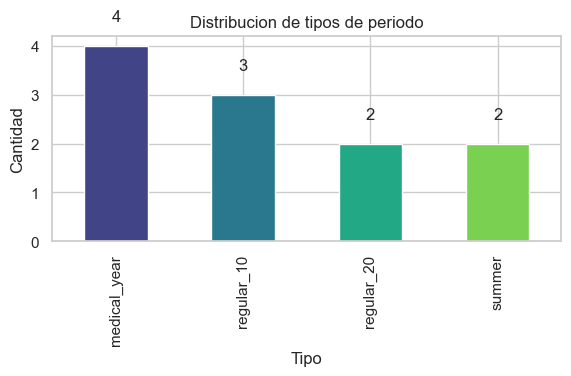

In [11]:
cal = build_calendar()
print(f"Periodos en calendario: {len(cal.all_codes())}")
print(f"  - Regulares: {len(cal.regular_codes())}")
print(f"  - Todos los codigos: {cal.all_codes()[-5:]} ... {cal.all_codes()[:3]}")
current = meta.get("current_period_code") or ""
target_code, target_label = cal.infer_target_period(current or None)
print(f"Periodo actual: {current}")
print(f"Periodo objetivo: {target_code} ({target_label})")

kinds = [cal.get(c).kind for c in cal.all_codes() if cal.get(c)]
kind_counts = pd.Series(kinds).value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
kind_counts.plot(kind="bar", ax=ax, color=sns.color_palette("viridis", len(kind_counts)))
ax.set_title("Distribucion de tipos de periodo")
ax.set_xlabel("Tipo")
ax.set_ylabel("Cantidad")
for i, v in enumerate(kind_counts.values):
    ax.text(i, v + 0.5, str(v), ha="center")
plt.tight_layout()
plt.show()

## 3. Grafo de mallas curriculares

Se cargan los archivos `Malla-*.json` del frontend y se construye un grafo
dirigido donde las aristas representan prerequisitos.

El algoritmo identifica:
- **Sucesores primarios** (misma area, semestre+1)
- **Prerequisitos directos** (arista explicita)
- **Grupos OR** (alternativas con `||`)

In [12]:
def iter_curricula(directory: Path | None = None) -> Iterator[tuple[str, dict]]:
    base = directory or CURRICULA_DIR
    for path in sorted(base.glob("Malla-*.json")):
        with open(path, encoding="utf-8") as f:
            data = json.load(f)
        curriculum_id = data.get("source_file") or path.stem
        yield curriculum_id, data


def parse_prereq_group(expr: str) -> list[str]:
    return [p.strip() for p in expr.split("||") if p.strip()]


def build_graph(courses: list[dict]) -> nx.DiGraph:
    g = nx.DiGraph()
    course_ids = {c["id"] for c in courses}
    for course in courses:
        cid = course["id"]
        g.add_node(cid, **{
            "code": course.get("code", cid),
            "credits": course.get("credits", 0),
            "semester": course.get("semester", 0),
            "type": course.get("type", ""),
            "area": course.get("area", cid[:3]),
        })
        for prereq_expr in course.get("prerequisites", []):
            for prereq in parse_prereq_group(prereq_expr):
                if prereq in course_ids:
                    g.add_edge(prereq, cid)
    return g


def graph_features(g: nx.DiGraph) -> dict[str, dict]:
    features: dict[str, dict] = {}
    for node in g.nodes:
        features[node] = {
            "in_degree": g.in_degree(node),
            "out_degree": g.out_degree(node),
            "semester": g.nodes[node].get("semester", 0),
            "credits": g.nodes[node].get("credits", 0),
            "unlocks_count": g.out_degree(node),
        }
    return features


def faculty_from_curriculum_id(curriculum_id: str) -> str | None:
    match = re.search(r"Malla-(?:academica-)?([A-Z]{3})", curriculum_id, re.I)
    return match.group(1).upper() if match else None

Mallas cargadas: 40
Cursos totales: 2164
Aristas totales: 1357


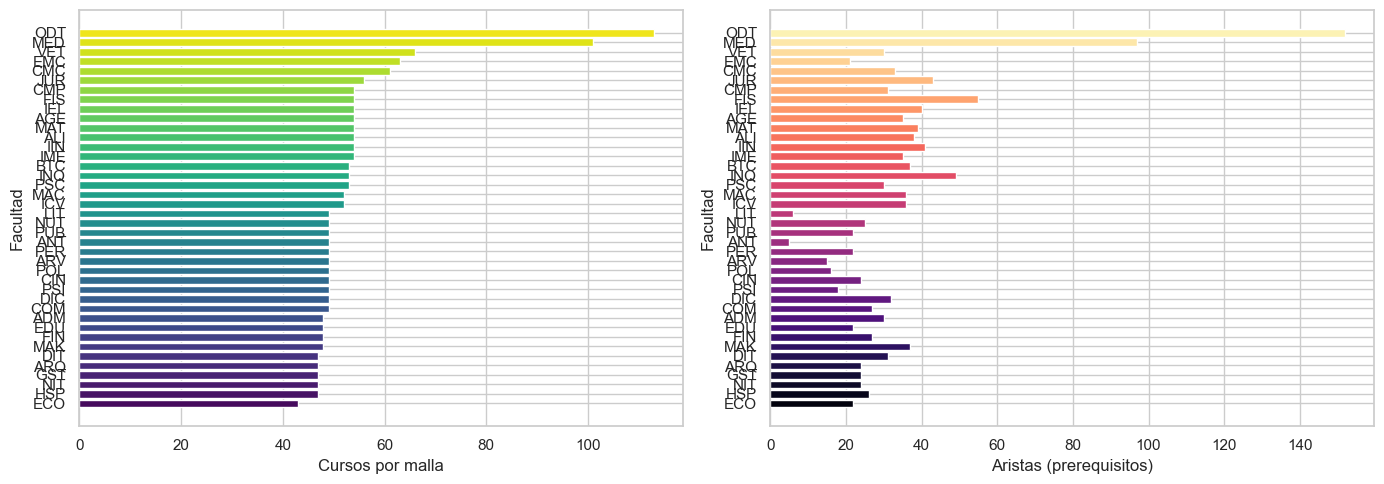

In [13]:
all_faculties = []
total_courses = 0
total_edges = 0
for cid, data in iter_curricula():
    fac = faculty_from_curriculum_id(cid)
    courses = data.get("courses", [])
    g = build_graph(courses)
    all_faculties.append({
        "curriculum_id": cid,
        "faculty": fac,
        "courses": len(courses),
        "edges": g.number_of_edges(),
    })
    total_courses += len(courses)
    total_edges += g.number_of_edges()

fac_df = pd.DataFrame(all_faculties)
print(f"Mallas cargadas: {len(fac_df)}")
print(f"Cursos totales: {total_courses}")
print(f"Aristas totales: {total_edges}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fac_df_sorted = fac_df.sort_values("courses", ascending=True)
axes[0].barh(fac_df_sorted["faculty"], fac_df_sorted["courses"], color=sns.color_palette("viridis", len(fac_df)))
axes[0].set_xlabel("Cursos por malla")
axes[0].set_ylabel("Facultad")
axes[1].barh(fac_df_sorted["faculty"], fac_df_sorted["edges"], color=sns.color_palette("magma", len(fac_df)))
axes[1].set_xlabel("Aristas (prerequisitos)")
axes[1].set_ylabel("Facultad")
plt.tight_layout()
plt.show()

## 4. Estadísticas históricas

Se procesa el historial de ofertas (`course_offer_history`) para cada curso
y se calculan métricas como promedio de estudiantes, secciones, último valor
regular, y tasa verano-a-regular.

El resultado es un `CourseHistoryStats` por código de oferta.

In [14]:
@dataclass
class PeriodOfferStats:
    period_code: str
    period_label: str
    sections: int
    total_students: int
    is_summer: bool
    period_kind: str = "unknown"


@dataclass
class CourseHistoryStats:
    course_code: str
    periods: list[PeriodOfferStats] = field(default_factory=list)
    avg_sections: float = 0.0
    avg_students: float = 0.0
    max_sections: int = 0
    num_periods: int = 0
    estimated_next_students: int = 0
    estimated_next_sections: int = 0
    last_regular_students: int = 0
    is_verano_course: bool = False
    summer_to_regular_rate: float = 0.0


def normalize_course_code(code: str) -> str:
    raw = code.strip().upper().replace(" ", "-")
    if re.match(r"^[A-Z]{2,5}-\d", raw):
        return raw
    bare = raw.replace("-", "")
    m = re.match(r"^([A-Z]{2,5})(\d.*)$", bare)
    if m:
        return f"{m.group(1)}-{m.group(2)}"
    return raw


def load_history_rows(history_path: Path | None = None) -> list[dict]:
    path = history_path or OUTPUT_DIR / "course_offer_history.json"
    if not path.exists():
        return []
    with open(path, encoding="utf-8") as f:
        rows = json.load(f)
    return rows if rows else []


def _is_usable_for_regular_avg(kind: str) -> bool:
    return is_regular(kind)


def _compute_seed_students(
    periods: list[PeriodOfferStats],
    target_period_code: str | None,
    cal_: AcademicCalendar,
    is_verano_course: bool,
) -> int:
    by_code = {p.period_code: p.total_students for p in periods}
    if is_verano_course:
        summers = [p for p in periods if p.period_kind == "summer"]
        return summers[-1].total_students if summers else 0
    if target_period_code:
        seed_period = cal_.seed_period_for_target(target_period_code)
        if seed_period and seed_period in by_code:
            base = by_code[seed_period]
            if cal_.get(target_period_code) and cal_.get(target_period_code).kind == "regular_10":
                summer_code = cal_.summer_before_regular(target_period_code)
                if summer_code and summer_code in by_code:
                    summer_cupo = by_code[summer_code]
                    rate = summer_cupo / max(base, 1) if base > 0 else 0.35
                    rate = min(0.6, max(0.1, rate))
                    return int(base + summer_cupo * rate * 0.5)
            return base
    regular = [p for p in periods if _is_usable_for_regular_avg(p.period_kind)]
    if regular:
        return regular[-1].total_students
    return periods[-1].total_students if periods else 0


def _compute_summer_rate(periods: list[PeriodOfferStats], cal_: AcademicCalendar) -> float:
    summers = [p for p in periods if p.period_kind == "summer"]
    regular = [p for p in periods if _is_usable_for_regular_avg(p.period_kind)]
    if not summers or not regular:
        return 0.0
    last_summer = summers[-1].total_students
    reg_after = [p for p in regular if p.period_code > summers[-1].period_code]
    ref = reg_after[0].total_students if reg_after else regular[-1].total_students
    if ref <= 0:
        return 0.0
    return min(0.95, max(0.05, last_summer / ref))


def aggregate_history_rows(
    rows: list[dict],
    *,
    target_period_code: str | None = None,
    calendar: AcademicCalendar | None = None,
    is_verano_course: bool = False,
) -> dict[str, CourseHistoryStats]:
    ACCENT_T = "Teoría"
    per_course_period: dict[str, dict[str, dict]] = {}
    for row in rows:
        if row.get("type") != ACCENT_T:
            continue
        code = normalize_course_code(str(row.get("course_code", "")))
        period_code = row.get("period_code") or row.get("period") or ""
        period_label = row.get("period") or period_code
        total = float(row.get("total") or 0)
        by_period = per_course_period.setdefault(code, {})
        current = by_period.setdefault(
            period_code,
            {"label": period_label, "sections": 0, "students": 0.0},
        )
        current["sections"] += 1
        current["students"] += total

    cal_ = calendar or build_calendar()
    result: dict[str, CourseHistoryStats] = {}
    for course_code, by_period in per_course_period.items():
        periods: list[PeriodOfferStats] = []
        for period_code in sorted(by_period.keys()):
            stats = by_period[period_code]
            kind = classify_period_kind(period_code)
            periods.append(PeriodOfferStats(
                period_code=period_code,
                period_label=stats["label"],
                sections=stats["sections"],
                total_students=int(stats["students"]),
                is_summer=is_summer_period(period_code),
                period_kind=kind,
            ))
        if is_verano_course:
            basis = [p for p in periods if p.period_kind == "summer"]
            if not basis:
                basis = periods
        else:
            basis = [p for p in periods if _is_usable_for_regular_avg(p.period_kind)]
            if not basis:
                basis = [p for p in periods if p.period_kind != "medical_year"]
            if not basis:
                basis = periods
        regular = [p for p in periods if _is_usable_for_regular_avg(p.period_kind)]
        avg_sections = sum(p.sections for p in basis) / len(basis) if basis else 0.0
        avg_students = sum(p.total_students for p in basis) / len(basis) if basis else 0.0
        max_sections = max((p.sections for p in periods), default=0)
        recent = [p.total_students for p in basis[-3:]]
        if len(recent) >= 2:
            estimated_next_students = round(sum(recent) / len(recent))
        else:
            estimated_next_students = round(avg_students)
        estimated_next_sections = max(
            1,
            round(estimated_next_students / STUDENTS_PER_SECTION) or round(avg_sections),
        )
        last_regular_students = _compute_seed_students(periods, target_period_code, cal_, is_verano_course)
        summer_rate = _compute_summer_rate(periods, cal_)
        result[course_code] = CourseHistoryStats(
            course_code=course_code,
            periods=periods,
            avg_sections=avg_sections,
            avg_students=avg_students,
            max_sections=max_sections,
            num_periods=len(periods),
            estimated_next_students=estimated_next_students,
            estimated_next_sections=estimated_next_sections,
            last_regular_students=last_regular_students,
            is_verano_course=is_verano_course,
            summer_to_regular_rate=summer_rate,
        )
    return result

Registros historicos cargados: 15597
Cursos con estadisticas: 2339
       num_periods  avg_students  avg_sections  max_sections  last_regular  \
count  2339.000000   2339.000000   2339.000000   2339.000000   2339.000000   
mean      2.519453     28.327419      1.901525      2.238991     28.398461   
std       1.323904     53.838657      3.282187      4.122141     63.903848   
min       1.000000      0.000000      1.000000      1.000000      0.000000   
25%       1.000000     11.500000      1.000000      1.000000     10.000000   
50%       2.000000     18.000000      1.000000      1.000000     18.000000   
75%       4.000000     25.000000      1.500000      2.000000     25.000000   
max       5.000000    957.250000     77.500000     83.000000   1300.000000   

       estimated_next  
count     2339.000000  
mean        28.498504  
std         56.761574  
min          0.000000  
25%         12.000000  
50%         18.000000  
75%         25.000000  
max       1015.000000  


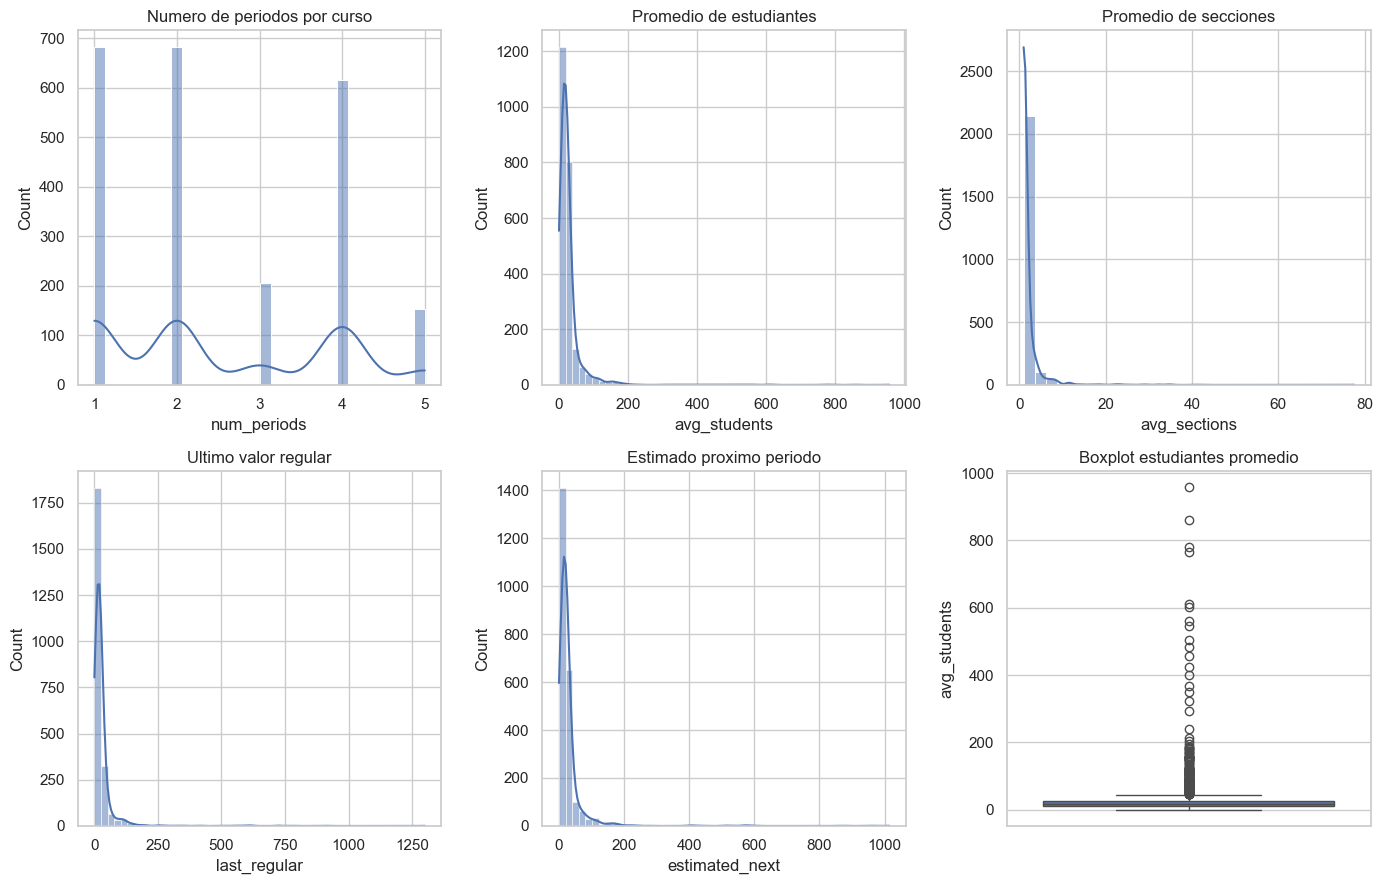

In [15]:
history_rows = load_history_rows()
print(f"Registros historicos cargados: {len(history_rows)}")

all_stats = aggregate_history_rows(history_rows, target_period_code=target_code, calendar=cal)
print(f"Cursos con estadisticas: {len(all_stats)}")

hist_df_rows = []
for code, h in all_stats.items():
    hist_df_rows.append({
        "course_code": code,
        "num_periods": h.num_periods,
        "avg_students": h.avg_students,
        "avg_sections": h.avg_sections,
        "max_sections": h.max_sections,
        "last_regular": h.last_regular_students,
        "estimated_next": h.estimated_next_students,
    })
hist_df = pd.DataFrame(hist_df_rows)
print(hist_df.describe())

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()
sns.histplot(hist_df["num_periods"], bins=30, ax=axes[0], kde=True)
axes[0].set_title("Numero de periodos por curso")
sns.histplot(hist_df["avg_students"], bins=50, ax=axes[1], kde=True)
axes[1].set_title("Promedio de estudiantes")
sns.histplot(hist_df["avg_sections"], bins=30, ax=axes[2], kde=True)
axes[2].set_title("Promedio de secciones")
sns.histplot(hist_df["last_regular"], bins=50, ax=axes[3], kde=True)
axes[3].set_title("Ultimo valor regular")
sns.histplot(hist_df["estimated_next"], bins=50, ax=axes[4], kde=True)
axes[4].set_title("Estimado proximo periodo")
sns.boxplot(data=hist_df, y="avg_students", ax=axes[5])
axes[5].set_title("Boxplot estudiantes promedio")
plt.tight_layout()
plt.show()

## 5. Propagación de demanda en el DAG

La propagación modela cómo los estudiantes que cursan o han cursado
prerrequisitos "fluyen" hacia cursos superiores usando tasas de transición.

- **Seeds**: estudiantes del último período regular (`last_regular_students`)
  y estudiantes cursando ahora (`in_progress`)
- **Transición**: `seed * transition_probability` a lo largo de aristas del DAG
- **OR groups**: se toma el máximo entre alternativas
- **Hops**: hasta `MAX_DAG_HOPS` (5) niveles

In [16]:
@dataclass
class CurriculumGraph:
    nodes: dict[str, dict]
    successors: dict[str, list[str]] = field(default_factory=dict)
    prerequisites: dict[str, list[str]] = field(default_factory=dict)


def build_curriculum_graph(courses: list[dict]) -> CurriculumGraph:
    ids = {c["id"] for c in courses}
    nodes = {c["id"]: c for c in courses}
    successors: dict[str, list[str]] = {cid: [] for cid in ids}
    prerequisites: dict[str, list[str]] = {}
    for course in courses:
        cid = course["id"]
        prereq_exprs = course.get("prerequisites") or []
        prerequisites[cid] = list(prereq_exprs)
        for expr in prereq_exprs:
            for prereq in parse_prereq_group(expr):
                if prereq not in ids:
                    continue
                successors.setdefault(prereq, []).append(cid)
    return CurriculumGraph(nodes=nodes, successors=successors, prerequisites=prerequisites)


def _is_direct_prerequisite(graph: CurriculumGraph, from_id: str, to_id: str) -> bool:
    for expr in graph.prerequisites.get(to_id, []):
        if from_id in parse_prereq_group(expr):
            return True
    return False


def _is_primary_successor(graph: CurriculumGraph, from_id: str, to_id: str) -> bool:
    from_c = graph.nodes.get(from_id)
    to_c = graph.nodes.get(to_id)
    if not from_c or not to_c:
        return False
    if from_c.get("area") != to_c.get("area"):
        return False
    if to_c.get("semester", 0) != from_c.get("semester", 0) + 1:
        return False
    same_area_next = [
        sid
        for sid in graph.successors.get(from_id, [])
        if (n := graph.nodes.get(sid))
        and n.get("area") == from_c.get("area")
        and n.get("semester", 0) == from_c.get("semester", 0) + 1
    ]
    if len(same_area_next) == 1:
        return same_area_next[0] == to_id
    return to_id in same_area_next


def default_transition_probability(graph: CurriculumGraph, from_id: str, to_id: str) -> float:
    if from_id not in graph.nodes or to_id not in graph.nodes:
        return P_OTHER
    if _is_primary_successor(graph, from_id, to_id):
        return P_SEQUENTIAL
    if _is_direct_prerequisite(graph, from_id, to_id):
        return P_SAME_AREA
    from_c = graph.nodes[from_id]
    to_c = graph.nodes[to_id]
    if from_c.get("area") == to_c.get("area"):
        return P_SAME_AREA
    return P_OTHER

In [17]:
@dataclass
class TransitionRateEntry:
    from_id: str = ""
    to_id: str = ""
    edge_type: str = "other"
    p: float = P_OTHER
    prior: float = P_OTHER
    n_pairs: int = 0
    source_students: float = 0.0
    target_students: float = 0.0
    curriculum_id: str = ""


@dataclass
class TransitionRateTable:
    by_edge: dict[tuple[str, str], TransitionRateEntry] = field(default_factory=dict)
    by_type: dict[str, TransitionRateEntry] = field(default_factory=dict)
    summer_rates: dict[str, float] = field(default_factory=dict)
    generated_at: str = ""
    version: int = 1

    def lookup(self, from_id: str, to_id: str, edge_type: str | None = None) -> float | None:
        entry = self.by_edge.get((from_id, to_id))
        if entry and entry.n_pairs >= 1:
            return entry.p
        et = edge_type or "other"
        type_entry = self.by_type.get(et)
        if type_entry and type_entry.n_pairs >= 1:
            return type_entry.p
        return None


_RATES_CACHE: TransitionRateTable | None = None


def get_rates() -> TransitionRateTable | None:
    global _RATES_CACHE
    if _RATES_CACHE is not None:
        return _RATES_CACHE
    p = TRANSITION_RATES_JSON
    if not p.exists():
        return None
    with open(p, encoding="utf-8") as f:
        data = json.load(f)
    table = TransitionRateTable(
        generated_at=data.get("generated_at", ""),
        version=int(data.get("version", 1)),
        summer_rates=dict(data.get("summer_rates") or {}),
    )
    for _key, row in (data.get("by_edge") or {}).items():
        entry = TransitionRateEntry(
            from_id=row["from_id"], to_id=row["to_id"],
            edge_type=row["edge_type"], p=float(row["p"]),
            prior=float(row.get("prior", P_OTHER)),
            n_pairs=int(row.get("n_pairs", 0)),
            source_students=float(row.get("source_students", 0)),
            target_students=float(row.get("target_students", 0)),
            curriculum_id=row.get("curriculum_id", ""),
        )
        table.by_edge[(entry.from_id, entry.to_id)] = entry
    for et, row in (data.get("by_type") or {}).items():
        table.by_type[et] = TransitionRateEntry(
            from_id="", to_id="", edge_type=et, p=float(row["p"]),
            prior=float(row.get("prior", P_OTHER)),
            n_pairs=int(row.get("n_pairs", 0)),
            source_students=float(row.get("source_students", 0)),
            target_students=float(row.get("target_students", 0)),
        )
    _RATES_CACHE = table
    return table


EdgeType = Literal["sequential", "cross_area_direct", "same_area", "other", "summer_to_regular"]

PRIOR_BY_TYPE: dict[EdgeType, float] = {
    "sequential": P_SEQUENTIAL,
    "cross_area_direct": P_SAME_AREA,
    "same_area": P_SAME_AREA,
    "other": P_OTHER,
    "summer_to_regular": P_SAME_AREA,
}


def classify_edge_type(graph: CurriculumGraph, from_id: str, to_id: str) -> EdgeType:
    if _is_primary_successor(graph, from_id, to_id):
        return "sequential"
    if _is_direct_prerequisite(graph, from_id, to_id):
        from_c = graph.nodes.get(from_id, {})
        to_c = graph.nodes.get(to_id, {})
        if from_c.get("area") != to_c.get("area"):
            return "cross_area_direct"
        return "same_area"
    from_c = graph.nodes.get(from_id, {})
    to_c = graph.nodes.get(to_id, {})
    if from_c.get("area") == to_c.get("area"):
        return "same_area"
    return "other"


def semester_delta(graph: CurriculumGraph, from_id: str, to_id: str) -> int:
    from_c = graph.nodes.get(from_id, {})
    to_c = graph.nodes.get(to_id, {})
    return max(1, int(to_c.get("semester", 0)) - int(from_c.get("semester", 0)))


def transition_probability(
    graph: CurriculumGraph,
    from_id: str,
    to_id: str,
    rates: TransitionRateTable | None = None,
) -> float:
    if rates is not None:
        et = classify_edge_type(graph, from_id, to_id)
        calibrated = rates.lookup(from_id, to_id, et)
        if calibrated is not None:
            return calibrated
    return default_transition_probability(graph, from_id, to_id)


def _propagate_inflow(
    graph: CurriculumGraph,
    seeds_by_course_id: dict[str, float],
    max_hops: int = MAX_DAG_HOPS,
    rates: TransitionRateTable | None = None,
) -> dict[str, float]:
    inflow: dict[str, float] = {}
    queue: list[tuple[str, float, int]] = []
    for course_id, course in graph.nodes.items():
        prereq_exprs = graph.prerequisites.get(course_id, [])
        if not prereq_exprs:
            continue
        direct_total = 0.0
        for expr in prereq_exprs:
            group = parse_prereq_group(expr)
            group_max = 0.0
            for prereq_id in group:
                seed = seeds_by_course_id.get(prereq_id, 0.0)
                if seed <= 0:
                    continue
                transferred = seed * transition_probability(graph, prereq_id, course_id, rates)
                group_max = max(group_max, transferred)
            direct_total += group_max
        if direct_total < MIN_DAG_FLOW:
            continue
        inflow[course_id] = inflow.get(course_id, 0.0) + direct_total
        queue.append((course_id, direct_total, 1))
    while queue:
        node_id, students, depth = queue.pop(0)
        if depth >= max_hops:
            continue
        for succ_id in graph.successors.get(node_id, []):
            transferred = students * transition_probability(graph, node_id, succ_id, rates)
            if transferred < MIN_DAG_FLOW:
                continue
            inflow[succ_id] = inflow.get(succ_id, 0.0) + transferred
            queue.append((succ_id, transferred, depth + 1))
    return inflow


def build_historical_seeds(
    courses: list[dict],
    history_by_offer: dict,
) -> dict[str, float]:
    seeds: dict[str, float] = {}
    for course in courses:
        offer = normalize_course_code(course["id"])
        hist = history_by_offer.get(offer)
        if hist and hist.last_regular_students > 0:
            seeds[course["id"]] = float(hist.last_regular_students)
    return seeds


def propagate_demand_from_sources(
    graph: CurriculumGraph,
    history_seeds: dict[str, float],
    cursando_seeds: dict[str, float],
    max_hops: int = MAX_DAG_HOPS,
    rates: TransitionRateTable | None = None,
) -> tuple[dict[str, float], dict[str, float], dict[str, float]]:
    inflow_hist = _propagate_inflow(graph, history_seeds, max_hops, rates)
    inflow_curs = _propagate_inflow(graph, cursando_seeds, max_hops, rates)
    total: dict[str, float] = {}
    for key in set(inflow_hist) | set(inflow_curs):
        total[key] = inflow_hist.get(key, 0.0) + inflow_curs.get(key, 0.0)
    return inflow_hist, inflow_curs, total

Malla Malla-academica-MAC: 52 cursos, 36 aristas
Seeds historicos: 41 cursos con last_regular > 0
Cursos con inflow historico: 29


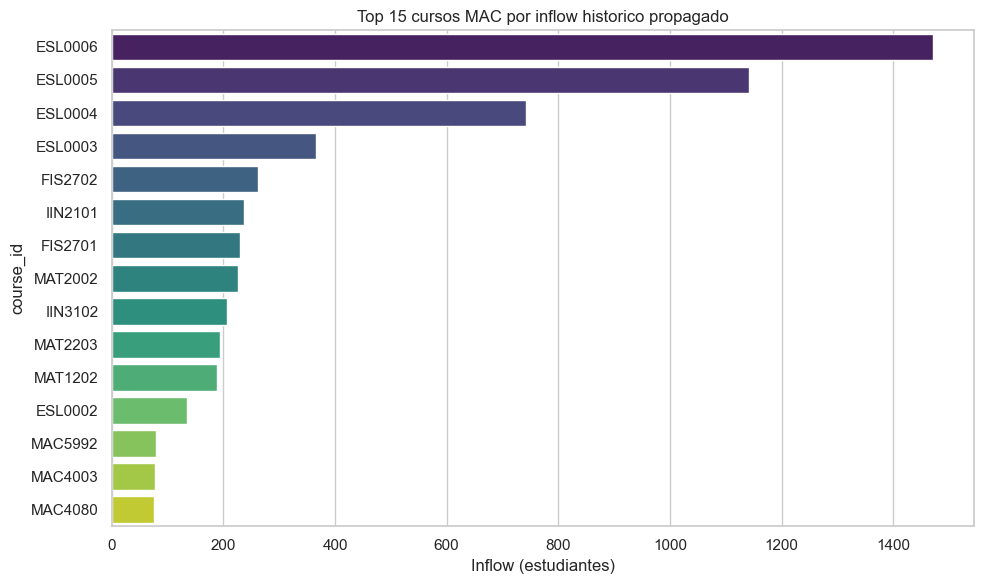

In [18]:
demo_cid, demo_data = None, None
for cid, data in iter_curricula():
    fac = faculty_from_curriculum_id(cid)
    if fac == "MAC":
        demo_cid, demo_data = cid, data
        break

if demo_data:
    demo_courses = demo_data.get("courses", [])
    demo_graph_nx = build_graph(demo_courses)
    demo_graph = build_curriculum_graph(demo_courses)
    print(f"Malla {demo_cid}: {len(demo_courses)} cursos, {demo_graph_nx.number_of_edges()} aristas")
    demo_offer_map = {}
    for c in demo_courses:
        offer = normalize_course_code(c["id"])
        if offer in all_stats:
            demo_offer_map[c["id"]] = all_stats[offer]
    demo_seeds = {cid: float(h.last_regular_students) for cid, h in demo_offer_map.items() if h.last_regular_students > 0}
    print(f"Seeds historicos: {len(demo_seeds)} cursos con last_regular > 0")
    demo_inflow_hist, _, demo_total = propagate_demand_from_sources(demo_graph, demo_seeds, {}, rates=get_rates())
    print(f"Cursos con inflow historico: {len(demo_inflow_hist)}")
    if demo_inflow_hist:
        inflow_df = pd.DataFrame([
            {"course_id": cid, "inflow": v}
            for cid, v in sorted(demo_inflow_hist.items(), key=lambda x: -x[1])[:15]
        ])
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(data=inflow_df, x="inflow", y="course_id", ax=ax, palette="viridis")
        ax.set_title("Top 15 cursos MAC por inflow historico propagado")
        ax.set_xlabel("Inflow (estudiantes)")
        plt.tight_layout()
        plt.show()
else:
    print("No se encontro malla MAC para demo")

## 6. Calibración de tasas de transición

Las tasas de transición se calibran empíricamente comparando pares de
períodos consecutivos: estudiantes en el prerrequisito en periodo `t` vs
estudiantes en el curso destino en periodo `t + delta`.

Se aplica **shrinkage Bayesiano** hacia priors fijos:
- `sequential` (80%): misma area, semestre siguiente
- `same_area` (50%): misma area pero no secuencial directo
- `cross_area_direct` (50%): prerequisito directo entre areas
- `other` (25%): resto

In [19]:
@dataclass
class RateAccumulator:
    source_students: float = 0.0
    target_students: float = 0.0
    n_pairs: int = 0


def _shrink_rate(obs_target: float, obs_source: float, prior: float, alpha: float) -> float:
    if obs_source <= 0:
        return prior
    p = (obs_target + alpha * prior) / (obs_source + alpha)
    return max(TRANSITION_RATE_MIN, min(TRANSITION_RATE_MAX, p))


def _cupo_by_period(history_stats: dict, offer_code: str) -> dict[str, int]:
    hist = history_stats.get(offer_code)
    if not hist:
        return {}
    return {p.period_code: p.total_students for p in hist.periods}


def calibrate_transitions(
    history_rows_: list[dict] | None = None,
    calendar: AcademicCalendar | None = None,
    *,
    max_period: str | None = None,
    alpha: float = TRANSITION_SHRINKAGE_ALPHA,
) -> TransitionRateTable:
    cal_ = calendar or build_calendar()
    stats = aggregate_history_rows(history_rows_ or load_history_rows())
    history_by_offer = {code: s for code, s in stats.items()}
    edge_acc: dict[tuple[str, str, str, EdgeType], RateAccumulator] = defaultdict(RateAccumulator)
    type_acc: dict[EdgeType, RateAccumulator] = defaultdict(RateAccumulator)
    summer_acc: dict[str, RateAccumulator] = defaultdict(RateAccumulator)
    regular_codes = [c for c in cal_.regular_codes() if not max_period or c < max_period]
    for curriculum_id, data in iter_curricula():
        courses = data.get("courses", [])
        if not courses:
            continue
        graph = build_curriculum_graph(courses)
        for course in courses:
            to_id = course["id"]
            to_offer = normalize_course_code(to_id)
            to_cupo = _cupo_by_period(history_by_offer, to_offer)
            for expr in course.get("prerequisites") or []:
                for from_id in parse_prereq_group(expr):
                    if from_id not in graph.nodes:
                        continue
                    from_offer = normalize_course_code(from_id)
                    from_cupo = _cupo_by_period(history_by_offer, from_offer)
                    et = classify_edge_type(graph, from_id, to_id)
                    delta = semester_delta(graph, from_id, to_id)
                    for src_period in regular_codes:
                        tgt_period = cal_.advance_regular(src_period, delta)
                        if not tgt_period:
                            continue
                        if max_period and tgt_period >= max_period:
                            continue
                        src_students = from_cupo.get(src_period, 0)
                        tgt_students = to_cupo.get(tgt_period, 0)
                        if src_students <= 0:
                            continue
                        key = (from_id, to_id, curriculum_id, et)
                        edge_acc[key].source_students += src_students
                        edge_acc[key].target_students += tgt_students
                        edge_acc[key].n_pairs += 1
                        type_acc[et].source_students += src_students
                        type_acc[et].target_students += tgt_students
                        type_acc[et].n_pairs += 1
            for reg_code in regular_codes:
                if cal_.get(reg_code) and cal_.get(reg_code).kind != "regular_10":
                    continue
                summer_code = cal_.summer_before_regular(reg_code)
                if not summer_code:
                    continue
                if max_period and reg_code >= max_period:
                    continue
                src_students = to_cupo.get(summer_code, 0)
                tgt_students = to_cupo.get(reg_code, 0)
                if src_students <= 0:
                    continue
                summer_acc[to_offer].source_students += src_students
                summer_acc[to_offer].target_students += tgt_students
                summer_acc[to_offer].n_pairs += 1
    table = TransitionRateTable(
        generated_at=datetime.now(timezone.utc).isoformat(),
        version=1,
    )
    for (from_id, to_id, curriculum_id, et), acc in edge_acc.items():
        prior = PRIOR_BY_TYPE.get(et, P_OTHER)
        p = _shrink_rate(acc.target_students, acc.source_students, prior, alpha)
        table.by_edge[(from_id, to_id)] = TransitionRateEntry(
            from_id=from_id, to_id=to_id, edge_type=et,
            p=p, prior=prior, n_pairs=acc.n_pairs,
            source_students=acc.source_students, target_students=acc.target_students,
            curriculum_id=curriculum_id,
        )
    for et, acc in type_acc.items():
        prior = PRIOR_BY_TYPE.get(et, P_OTHER)
        p = _shrink_rate(acc.target_students, acc.source_students, prior, alpha)
        table.by_type[et] = TransitionRateEntry(
            from_id="*", to_id="*", edge_type=et,
            p=p, prior=prior, n_pairs=acc.n_pairs,
            source_students=acc.source_students, target_students=acc.target_students,
        )
    for offer, acc in summer_acc.items():
        if acc.source_students > 0:
            raw = acc.target_students / acc.source_students
            table.summer_rates[offer] = round(max(TRANSITION_RATE_MIN, min(TRANSITION_RATE_MAX, raw)), 4)
    return table


def save_transition_rates(
    table: TransitionRateTable,
    path: Path | None = None,
    public_path: Path | None = None,
) -> tuple[Path, Path]:
    dest = path or TRANSITION_RATES_JSON
    pub = public_path or PUBLIC_TRANSITION_RATES_JSON
    dest.parent.mkdir(parents=True, exist_ok=True)
    pub.parent.mkdir(parents=True, exist_ok=True)
    payload = {
        "generated_at": table.generated_at,
        "version": table.version,
        "by_edge": {
            f"{a}->{b}": {
                "from_id": e.from_id, "to_id": e.to_id,
                "edge_type": e.edge_type, "p": round(e.p, 4),
                "prior": e.prior, "n_pairs": e.n_pairs,
                "source_students": round(e.source_students, 1),
                "target_students": round(e.target_students, 1),
                "curriculum_id": e.curriculum_id,
            }
            for (a, b), e in table.by_edge.items()
        },
        "by_type": {
            k: {
                "from_id": v.from_id, "to_id": v.to_id,
                "edge_type": v.edge_type, "p": round(v.p, 4),
                "prior": v.prior, "n_pairs": v.n_pairs,
                "source_students": round(v.source_students, 1),
                "target_students": round(v.target_students, 1),
            }
            for k, v in table.by_type.items()
        },
        "summer_rates": table.summer_rates,
    }
    with open(dest, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2)
    with open(pub, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2)
    return dest, pub

Calibrando tasas de transicion...
Tasas calibradas: 814 aristas, 3 tipos
Guardadas en /Users/joshuareinoso/Documents/GitHub/malla-curricular-interactiva/predictor/output/transition_rates.json
Copia publica en /Users/joshuareinoso/Documents/GitHub/malla-curricular-interactiva/frontend/public/data/transition_rates.json

             type        p  prior  n_pairs   source
        same_area 0.842643    0.5     1229 215012.0
       sequential 0.782792    0.8     1556 199080.0
cross_area_direct 0.236343    0.5      592  75766.0


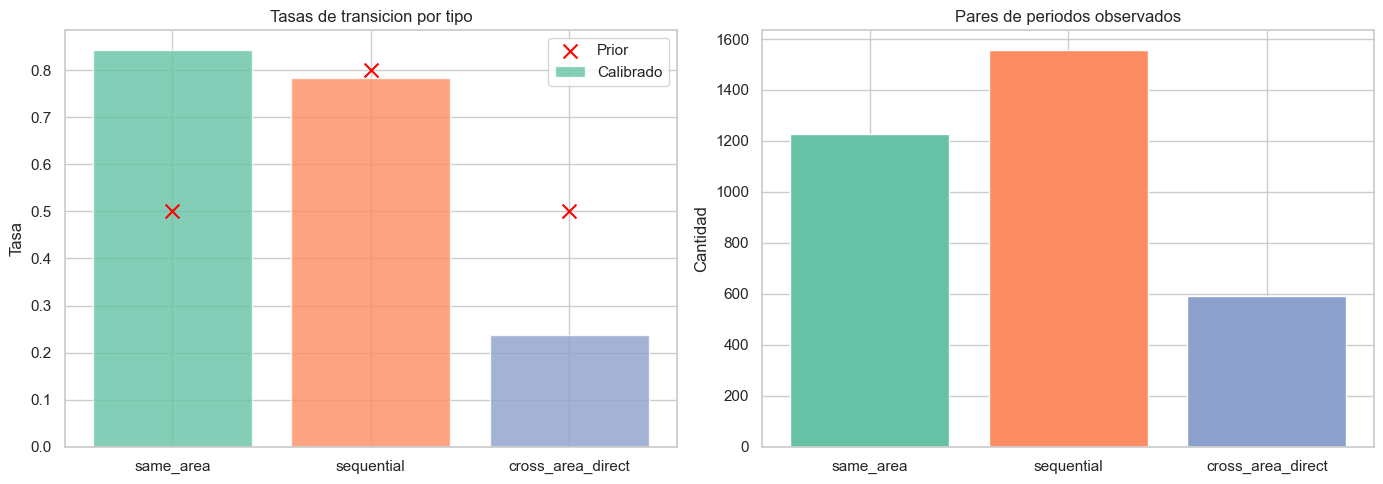

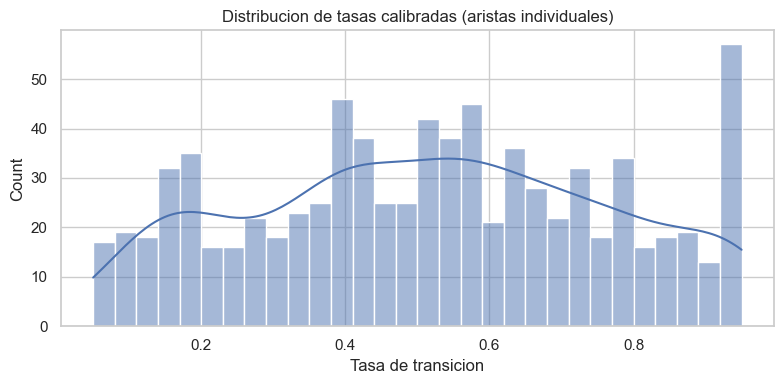

In [20]:
rates = None
if not SKIP_CALIBRATION or FORCE_RECOMPUTE:
    print("Calibrando tasas de transicion...")
    rates = calibrate_transitions(history_rows, cal)
    cal_path, pub_path = save_transition_rates(rates)
    print(f"Tasas calibradas: {len(rates.by_edge)} aristas, {len(rates.by_type)} tipos")
    print(f"Guardadas en {cal_path}")
    print(f"Copia publica en {pub_path}")
else:
    rates = get_rates()
    if rates:
        print(f"Tasas cargadas desde cache:")
        print(f"  Aristas: {len(rates.by_edge)}")
        print(f"  Tipos: {len(rates.by_type)}")
        print(f"  Verano: {len(rates.summer_rates)} cursos")

if rates:
    type_rows = []
    for et, entry in rates.by_type.items():
        type_rows.append({
            "type": et,
            "p": entry.p,
            "prior": entry.prior,
            "n_pairs": entry.n_pairs,
            "source": entry.source_students,
        })
    type_df = pd.DataFrame(type_rows)
    print()
    print(type_df.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = sns.color_palette("Set2", len(type_df))
    axes[0].bar(type_df["type"], type_df["p"], color=colors, alpha=0.8, label="Calibrado")
    axes[0].scatter(range(len(type_df)), type_df["prior"], color="red", marker="x", s=100, label="Prior")
    axes[0].set_title("Tasas de transicion por tipo")
    axes[0].set_ylabel("Tasa")
    axes[0].legend()
    axes[1].bar(type_df["type"], type_df["n_pairs"], color=colors)
    axes[1].set_title("Pares de periodos observados")
    axes[1].set_ylabel("Cantidad")
    plt.tight_layout()
    plt.show()

    edge_ps = [e.p for e in rates.by_edge.values()]
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.histplot(edge_ps, bins=30, ax=ax, kde=True)
    ax.set_title("Distribucion de tasas calibradas (aristas individuales)")
    ax.set_xlabel("Tasa de transicion")
    plt.tight_layout()
    plt.show()

## 7. Fórmula híbrida de demanda

La fórmula híbrida combina 5 señales para estimar estudiantes y 5 para secciones:

**Estudiantes:**
- `estimated_next_students` (media últimos 3) × 45%
- `avg_students` (promedio histórico) × 15%
- `inflow_from_history` (propagación DAG histórica) × 25%
- `inflow_from_cursando` (propagación DAG actual) × 10%
- `planned_count` (planificados en plataforma) × 5%

**Secciones:** combinación similar + `estimated / STUDENTS_PER_SECTION`.
Si el curso no tiene historia, se usa `planned + inflow_hist + inflow_curs`.

In [21]:
DemandTrend = Literal["up", "down", "stable", "new"]


def is_stable_offering(history: CourseHistoryStats, trend: DemandTrend) -> bool:
    if trend in ("down", "new"):
        return False
    regular = [p for p in history.periods if _is_usable_for_regular_avg(p.period_kind)]
    if len(regular) < 2:
        return False
    last = regular[-1].total_students
    prev = regular[-2].total_students
    return last >= MIN_STABLE_ENROLLMENT and prev >= MIN_STABLE_ENROLLMENT


def _compute_trend(
    history: CourseHistoryStats,
    estimate: int,
    dag_inflow: float,
) -> DemandTrend:
    regular = [p for p in history.periods if _is_usable_for_regular_avg(p.period_kind)]
    if len(regular) < 2 and dag_inflow <= 0:
        return "stable"
    last = regular[-1].total_students if regular else 0
    prev = regular[-2].total_students if len(regular) >= 2 else last
    baseline = last / prev if prev > 0 else 1.0
    reference = max(last, dag_inflow, estimate)
    projected = estimate / reference if reference > 0 else 1.0
    ratio = projected * 0.55 + baseline * 0.45
    if ratio > 1.08:
        return "up"
    if ratio < 0.92:
        return "down"
    return "stable"


def compute_demand_prediction(
    planned_next: float,
    inflow_from_history: float,
    inflow_from_cursando: float,
    history: CourseHistoryStats | None,
) -> tuple[int, int, DemandTrend]:
    if not history or history.num_periods == 0:
        estimated = round(planned_next + inflow_from_history + inflow_from_cursando)
        sections = max(1, round(estimated / STUDENTS_PER_SECTION))
        trend: DemandTrend = "up" if estimated > 0 else "new"
        return estimated, sections, trend
    estimated = round(
        history.estimated_next_students * W_EST_NEXT
        + history.avg_students * W_AVG_STUDENTS
        + inflow_from_history * W_INFLOW_HIST
        + inflow_from_cursando * W_INFLOW_CURS
        + planned_next * W_PLANNED
    )
    trend = _compute_trend(history, estimated, inflow_from_history + inflow_from_cursando)
    if is_stable_offering(history, trend):
        estimated = max(estimated, MIN_STABLE_ENROLLMENT)
    sections = max(
        1,
        round(
            history.estimated_next_sections * W_SEC_EST
            + history.avg_sections * W_SEC_AVG
            + (estimated / STUDENTS_PER_SECTION) * W_SEC_FROM_EST
            + (inflow_from_history / STUDENTS_PER_SECTION) * W_SEC_INFLOW_HIST
            + (inflow_from_cursando / STUDENTS_PER_SECTION) * W_SEC_INFLOW_CURS
        ),
    )
    return estimated, sections, trend

In [22]:
test_planned = 5.0
test_inflow_hist = 30.0
test_inflow_curs = 10.0
if all_stats:
    sample_code = next(iter(all_stats))
    sample_hist = all_stats[sample_code]
    est, sec, trend = compute_demand_prediction(test_planned, test_inflow_hist, test_inflow_curs, sample_hist)
    print(f"Curso con historia ({sample_code}): estimado={est}, secciones={sec}, tendencia={trend}")
    print(f"  avg_students={sample_hist.avg_students:.0f}, "
          f"estimated_next={sample_hist.estimated_next_students}, "
          f"num_periods={sample_hist.num_periods}")
est_no, sec_no, trend_no = compute_demand_prediction(test_planned, test_inflow_hist, test_inflow_curs, None)
print(f"Curso SIN historia: estimado={est_no}, secciones={sec_no}, tendencia={trend_no}")
print("  (deberia ser planned + inflow_hist + inflow_curs = 45)")

Curso con historia (ADM-0001): estimado=113, secciones=4, tendencia=down
  avg_students=174, estimated_next=174, num_periods=5
Curso SIN historia: estimado=45, secciones=2, tendencia=up
  (deberia ser planned + inflow_hist + inflow_curs = 45)


### Visualización de los pesos de la fórmula

Los gráficos siguientes muestran cómo se distribuyen los pesos en la estimación
de estudiantes y secciones, y una descomposición de la contribución de cada
componente al estimado final usando un ejemplo real.

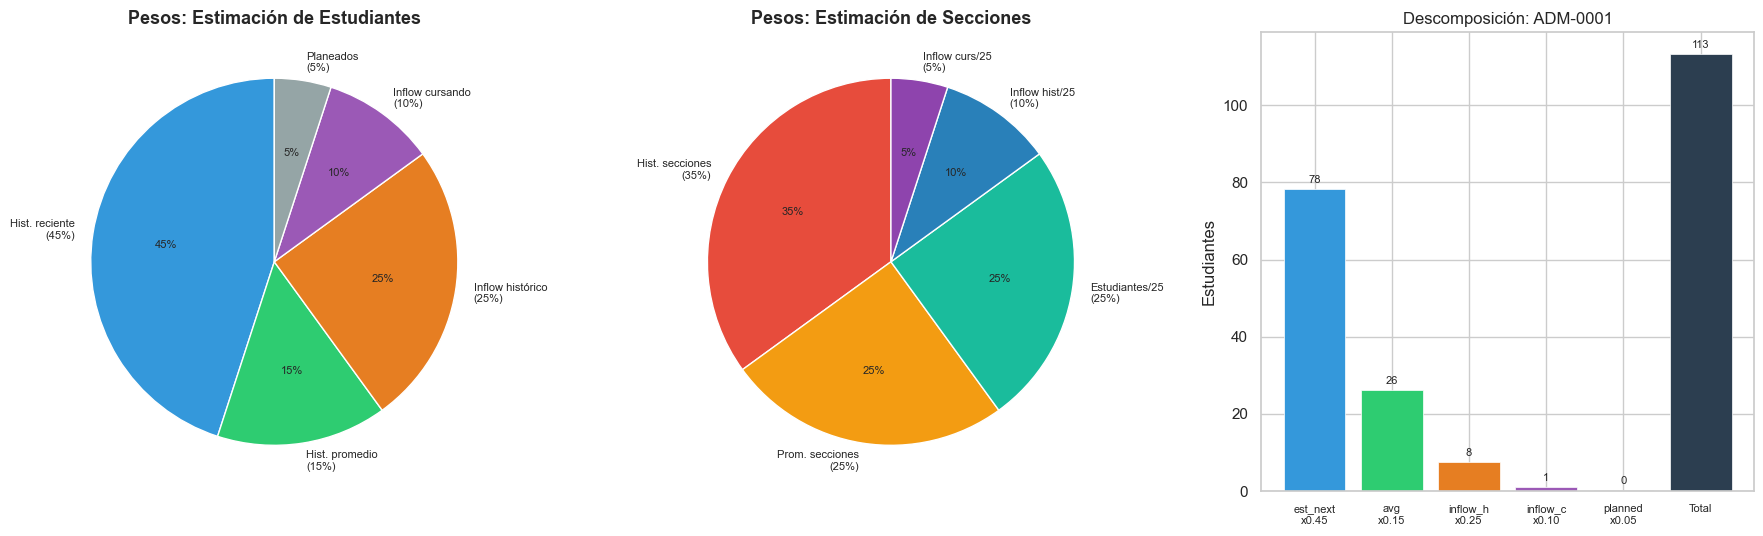

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# 1. Pie: pesos estimación estudiantes
student_labels = ["Hist. reciente\n(45%)", "Hist. promedio\n(15%)",
                  "Inflow histórico\n(25%)", "Inflow cursando\n(10%)", "Planeados\n(5%)"]
student_vals = [W_EST_NEXT, W_AVG_STUDENTS, W_INFLOW_HIST, W_INFLOW_CURS, W_PLANNED]
colors_s = ["#3498DB", "#2ECC71", "#E67E22", "#9B59B6", "#95A5A6"]
axes[0].pie(student_vals, labels=student_labels, autopct="%1.0f%%",
            colors=colors_s, startangle=90, textprops={"fontsize": 8})
axes[0].set_title("Pesos: Estimación de Estudiantes", fontsize=13, fontweight="bold")

# 2. Pie: pesos estimación secciones
sec_labels = ["Hist. secciones\n(35%)", "Prom. secciones\n(25%)",
              "Estudiantes/25\n(25%)", "Inflow hist/25\n(10%)", "Inflow curs/25\n(5%)"]
sec_vals = [W_SEC_EST, W_SEC_AVG, W_SEC_FROM_EST, W_SEC_INFLOW_HIST, W_SEC_INFLOW_CURS]
colors_c = ["#E74C3C", "#F39C12", "#1ABC9C", "#2980B9", "#8E44AD"]
axes[1].pie(sec_vals, labels=sec_labels, autopct="%1.0f%%",
            colors=colors_c, startangle=90, textprops={"fontsize": 8})
axes[1].set_title("Pesos: Estimación de Secciones", fontsize=13, fontweight="bold")

# 3. Waterfall: contribucion con dato real
if all_stats:
    sample_code = next(iter(all_stats))
    sample_hist = all_stats[sample_code]
    tp = 5.0; ih = 30.0; ic = 10.0
    comps = {
        "est_next\nx0.45": sample_hist.estimated_next_students * W_EST_NEXT,
        "avg\nx0.15": sample_hist.avg_students * W_AVG_STUDENTS,
        "inflow_h\nx0.25": ih * W_INFLOW_HIST,
        "inflow_c\nx0.10": ic * W_INFLOW_CURS,
        "planned\nx0.05": tp * W_PLANNED,
    }
    vals = list(comps.values())
    total = sum(vals)
    colors_wf = [colors_s[i] for i in range(5)] + ["#2C3E50"]
    bars = axes[2].bar(range(6), vals + [total], color=colors_wf, edgecolor="white", linewidth=0.5)
    axes[2].set_xticks(range(6))
    axes[2].set_xticklabels(list(comps.keys()) + ["Total"], fontsize=8)
    axes[2].set_ylabel("Estudiantes")
    axes[2].set_title(f"Descomposición: {sample_code[:12]}", fontsize=12)
    for bar, val in zip(bars, vals + [total]):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f"{val:.0f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

## 8. Feature engineering completo

Construimos el `DataFrame` de features combinando:
- Estadísticas históricas por curso
- Propagación DAG (inflow histórico + cursando)
- Planificación en plataforma (`planned_count` + `in_progress_count`)
- Métricas de grafo (in_degree, out_degree, semester, credits)
- Resultados de la fórmula híbrida

Se itera sobre todas las mallas curriculares y se filtran cursos según `FACULTY`.

In [24]:
def _is_verano_block(block: str | None) -> bool:
    return "verano" in (block or "").lower()


def load_platform_counts(
    progress_path: Path | None = None,
    *,
    curriculum_id: str | None = None,
) -> tuple[dict[str, int], dict[str, int]]:
    path = progress_path or OUTPUT_DIR / "user_progress.json"
    if not path.exists():
        return {}, {}
    with open(path, encoding="utf-8") as f:
        rows = json.load(f)
    cursando: dict[str, int] = defaultdict(int)
    planned: dict[str, int] = defaultdict(int)
    for row in rows:
        if curriculum_id and row.get("curriculum_id") != curriculum_id:
            continue
        for cid in row.get("in_progress_courses") or []:
            cursando[normalize_course_code(str(cid))] += 1
        for cid in row.get("planned_courses") or []:
            planned[normalize_course_code(str(cid))] += 1
    return dict(cursando), dict(planned)


def _platform_by_course_id(
    courses: list[dict],
    cursando_offer: dict[str, int],
    planned_offer: dict[str, int],
) -> tuple[dict[str, int], dict[str, int]]:
    cursando: dict[str, int] = {}
    planned: dict[str, int] = {}
    for course in courses:
        cid = course["id"]
        keys = {
            normalize_course_code(cid),
            normalize_course_code(course.get("code", cid)),
        }
        c_sum = sum(cursando_offer.get(k, 0) for k in keys)
        p_sum = sum(planned_offer.get(k, 0) for k in keys)
        if c_sum:
            cursando[cid] = c_sum
        if p_sum:
            planned[cid] = p_sum
    return cursando, planned


def build_feature_frame(
    faculty: str | None = None,
    *,
    rates_: TransitionRateTable | None = None,
    use_calibrated_rates: bool = True,
    target_period_code: str | None = None,
    history_rows_: list[dict] | None = None,
) -> pd.DataFrame:
    if rates_ is None and use_calibrated_rates:
        rates_ = get_rates()
    meta_ = load_offer_metadata()
    current_period_ = meta_.get("current_period_code") or ""
    cal_ = build_calendar()
    inferred_target, target_label_ = cal_.infer_target_period(current_period_ or None)
    target = target_period_code or inferred_target
    rows_ = history_rows_ if history_rows_ is not None else load_history_rows()
    records: list[dict] = []
    for curriculum_id, data in iter_curricula():
        fac = faculty_from_curriculum_id(curriculum_id)
        if faculty and fac != faculty:
            continue
        courses = data.get("courses", [])
        if not courses:
            continue
        cursando_offer, planned_offer = load_platform_counts(curriculum_id=curriculum_id)
        verano_ids = {c["id"] for c in courses if _is_verano_block(c.get("block"))}
        history_stats: dict = {}
        for course in courses:
            offer = normalize_course_code(course["id"])
            is_verano = course["id"] in verano_ids
            partial = aggregate_history_rows(
                [r for r in rows_ if normalize_course_code(str(r.get("course_code", ""))) == offer],
                target_period_code=target,
                calendar=cal_,
                is_verano_course=is_verano,
            )
            if offer in partial:
                history_stats[offer] = partial[offer]
        global_stats = aggregate_history_rows(rows_, target_period_code=target, calendar=cal_)
        for code, stat in global_stats.items():
            history_stats.setdefault(code, stat)
        graph = build_curriculum_graph(courses)
        nx_graph = build_graph(courses)
        feats = graph_features(nx_graph)
        hist_seeds = build_historical_seeds(courses, history_stats)
        cursando_by_id, planned_by_id = _platform_by_course_id(courses, cursando_offer, planned_offer)
        inflow_hist, inflow_curs, total_inflow = propagate_demand_from_sources(
            graph, hist_seeds,
            {k: float(v) for k, v in cursando_by_id.items()},
            rates=rates_,
        )
        for course in courses:
            course_id = course["id"]
            if faculty and not course_id.startswith(faculty):
                continue
            offer_code = normalize_course_code(course_id)
            hist = history_stats.get(offer_code)
            planned_count = planned_by_id.get(course_id, 0)
            h_inflow = inflow_hist.get(course_id, 0.0)
            c_inflow = inflow_curs.get(course_id, 0.0)
            estimated_students, suggested_sections, trend = compute_demand_prediction(
                float(planned_count), h_inflow, c_inflow, hist,
            )
            actual_at_target = 0
            if target and hist:
                for p in hist.periods:
                    if p.period_code == target:
                        actual_at_target = p.total_students
                        break
            meta_g = feats.get(course_id, {})
            records.append({
                "course_id": course_id,
                "offer_code": offer_code,
                "title": course.get("title", offer_code),
                "faculty": fac,
                "curriculum_id": curriculum_id,
                "planned_count": planned_count,
                "in_progress_count": cursando_by_id.get(course_id, 0),
                "inflow_from_history": round(h_inflow, 2),
                "inflow_from_cursando": round(c_inflow, 2),
                "propagated_students": round(total_inflow.get(course_id, 0.0), 2),
                "avg_historical": hist.avg_sections if hist else 0.0,
                "avg_students": hist.avg_students if hist else 0.0,
                "estimated_next_students": hist.estimated_next_students if hist else 0,
                "max_historical": hist.max_sections if hist else 0,
                "num_periods": hist.num_periods if hist else 0,
                "last_regular_students": hist.last_regular_students if hist else 0,
                "summer_to_regular_rate": hist.summer_to_regular_rate if hist else 0.0,
                "estimated_students": estimated_students,
                "suggested_sections": suggested_sections,
                "actual_students_at_target": actual_at_target,
                "target_period_code": target,
                "current_period_code": current_period_,
                "trend": trend,
                "in_degree": meta_g.get("in_degree", 0),
                "out_degree": meta_g.get("out_degree", 0),
                "semester": meta_g.get("semester", 0),
                "credits": meta_g.get("credits", 0),
                "unlocks_count": meta_g.get("unlocks_count", 0),
            })
    df = pd.DataFrame(records)
    df.attrs["target_period_code"] = target
    df.attrs["target_period_label"] = target_label_
    df.attrs["current_period_code"] = current_period_
    return df

In [25]:
print("Construyendo feature frame...")
features = build_feature_frame(faculty=FACULTY_FILTER, rates_=rates)
print(f"Feature frame: {len(features)} registros, {len(features.columns)} columnas")
print(f"Periodo objetivo: {features.attrs.get('target_period_label', '?')}")
print(f"Facultad filtrada: {FACULTY_FILTER or 'TODAS'}")
print()
summary_cols = [
    "estimated_students", "suggested_sections", "num_periods",
    "inflow_from_history", "inflow_from_cursando", "planned_count",
]
print(features[summary_cols].describe())

trend_counts = features["trend"].value_counts()
print(f"\nDistribucion de tendencias:\n{trend_counts}")

fig, axes = plt.subplots(2, 3, figsize=(14, 10))
axes = axes.flatten()
sns.histplot(features["estimated_students"], bins=50, ax=axes[0], kde=True)
axes[0].set_title("Distribucion de estimated_students")
sns.histplot(features["suggested_sections"], bins=20, ax=axes[1], kde=True)
axes[1].set_title("Secciones sugeridas")
trend_counts.plot(kind="bar", ax=axes[2], color=sns.color_palette("Set2", 4))
axes[2].set_title("Tendencias")
axes[2].set_xlabel("Trend")
axes[2].set_ylabel("Cursos")
sns.scatterplot(data=features, x="avg_students", y="estimated_students", hue="trend", alpha=0.5, ax=axes[3])
axes[3].set_title("Estimated vs Avg Historical")
sns.scatterplot(data=features, x="inflow_from_history", y="estimated_students", hue="trend", alpha=0.5, ax=axes[4])
axes[4].set_title("Estimated vs Inflow History")
sns.boxplot(data=features, y="estimated_students", x="trend", ax=axes[5])
axes[5].set_title("Estimated por tendencia")
plt.tight_layout()
plt.show()

Construyendo feature frame...
Feature frame: 0 registros, 0 columnas
Periodo objetivo: Primer Semestre 2026/2027
Facultad filtrada: None



KeyError: "None of [Index(['estimated_students', 'suggested_sections', 'num_periods',\n       'inflow_from_history', 'inflow_from_cursando', 'planned_count'],\n      dtype='object')] are in the [columns]"

## 9. Entrenamiento del modelo GBR

Se entrena un **GradientBoostingRegressor** sobre los cursos con historia
usando `actual_students_at_target` como target cuando está disponible (cursos
de períodos pasados), o `estimated_students` como pseudo-label.

Features: `planned_count`, `in_progress_count`, `inflow_from_history`,
`inflow_from_cursando`, `estimated_next_students`, `avg_students`,
`last_regular_students`, `summer_to_regular_rate`, `in_degree`,
`out_degree`, `semester`, `credits`, `num_periods`.

In [ ]:
FEATURE_COLS = [
    "planned_count",
    "in_progress_count",
    "inflow_from_history",
    "inflow_from_cursando",
    "estimated_next_students",
    "avg_students",
    "last_regular_students",
    "summer_to_regular_rate",
    "in_degree",
    "out_degree",
    "semester",
    "credits",
    "num_periods",
]


def train_demand_model(features: pd.DataFrame) -> GradientBoostingRegressor | None:
    labeled = features[features["num_periods"] > 0].copy()
    if len(labeled) < 20:
        return None
    if "actual_students_at_target" in labeled.columns:
        has_actual = labeled["actual_students_at_target"].fillna(0) > 0
        if has_actual.sum() >= 20:
            train_df = labeled[has_actual].copy()
            y = train_df["actual_students_at_target"].fillna(0)
        else:
            train_df = labeled
            y = labeled["estimated_students"].fillna(0)
    else:
        train_df = labeled
        y = labeled["estimated_students"].fillna(0)
    X = train_df[FEATURE_COLS].fillna(0)
    if y.nunique() < 2:
        return None
    if "target_period_code" in train_df.columns and train_df["target_period_code"].nunique() > 1:
        sorted_df = train_df.sort_values("target_period_code")
        split_idx = max(1, int(len(sorted_df) * 0.8))
        X_train = X.iloc[:split_idx]
        y_train = y.iloc[:split_idx]
    else:
        X_train = X
        y_train = y
    model = GradientBoostingRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    return model

In [ ]:
model = None
if not SKIP_GBR:
    print("Entrenando modelo GBR...")
    model = train_demand_model(features)
    if model is not None:
        print(f"Modelo GBR entrenado: {len(model.feature_importances_)} features")
        imp_df = pd.DataFrame({
            "feature": FEATURE_COLS,
            "importance": model.feature_importances_,
        }).sort_values("importance", ascending=False)
        print(imp_df.to_string(index=False))
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(data=imp_df, x="importance", y="feature", ax=ax, palette="viridis")
        ax.set_title("Importancia de features en GBR")
        ax.set_xlabel("Importancia relativa")
        plt.tight_layout()
        plt.show()
    else:
        print("No se pudo entrenar GBR (datos insuficientes)")
else:
    print("GBR saltado (SKIP_GBR=True)")

if len(features) > 0:
    corr_cols = [c for c in FEATURE_COLS if c in features.columns]
    corr_df = features[corr_cols + ["estimated_students"]].corr()
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
    ax.set_title("Correlacion entre features")
    plt.tight_layout()
    plt.show()

## 10. Aplicación del modelo

Se aplica el modelo entrenado (o solo la fórmula híbrida si no hay GBR)
a todos los cursos. Si `PREFER_GBR=True` y el GBR está disponible, se usan
sus estimados como primarios.

In [ ]:
def apply_model(
    features: pd.DataFrame,
    model: GradientBoostingRegressor | None,
    *,
    prefer_gbr: bool = True,
) -> pd.DataFrame:
    out = features.copy()
    out["model"] = "hybrid"
    out["predicted_seats"] = out["estimated_students"]
    out["predicted_sections"] = out["suggested_sections"]
    out["gbr_available"] = False
    if model is None:
        return out
    has_history = out["num_periods"].fillna(0) > 0
    if not has_history.any():
        return out
    X = out.loc[has_history, FEATURE_COLS].fillna(0)
    preds = np.clip(model.predict(X), 1, None)
    out.loc[has_history, "gbr_estimated_students"] = np.round(preds).astype(int)
    out.loc[has_history, "gbr_suggested_sections"] = np.maximum(
        1,
        np.round(out.loc[has_history, "gbr_estimated_students"] / STUDENTS_PER_SECTION).astype(int),
    )
    out.loc[has_history, "gbr_available"] = True
    out.loc[has_history, "model"] = "hybrid+gbr"
    if prefer_gbr:
        mask = out["gbr_available"].fillna(False)
        out.loc[mask, "predicted_seats"] = out.loc[mask, "gbr_estimated_students"]
        out.loc[mask, "predicted_sections"] = out.loc[mask, "gbr_suggested_sections"]
    return out

In [ ]:
result = apply_model(features, model, prefer_gbr=PREFER_GBR)
print(f"Predicciones generadas: {len(result)}")
model_types = result["model"].value_counts()
print(f"Tipo de modelo usado:\n{model_types}")

if model is not None and result["gbr_available"].any():
    gbr_subset = result[result["gbr_available"]]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(gbr_subset["estimated_students"], gbr_subset["gbr_estimated_students"],
                   alpha=0.3, c="steelblue", edgecolors="none")
    max_val = gbr_subset[["estimated_students", "gbr_estimated_students"]].max().max()
    axes[0].plot([0, max_val], [0, max_val], "r--", linewidth=1)
    axes[0].set_xlabel("Hybrid estimated_students")
    axes[0].set_ylabel("GBR estimated_students")
    axes[0].set_title("Hybrid vs GBR (cursos con historia)")
    axes[1].scatter(gbr_subset["suggested_sections"], gbr_subset["gbr_suggested_sections"],
                   alpha=0.3, c="coral", edgecolors="none")
    max_sec = gbr_subset[["suggested_sections", "gbr_suggested_sections"]].max().max()
    axes[1].plot([0, max_sec], [0, max_sec], "r--", linewidth=1)
    axes[1].set_xlabel("Hybrid sections")
    axes[1].set_ylabel("GBR sections")
    axes[1].set_title("Hybrid vs GBR (secciones)")
    plt.tight_layout()
    plt.show()

    result["gbr_diff"] = result["gbr_estimated_students"] - result["estimated_students"]
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.histplot(result["gbr_diff"].dropna(), bins=50, ax=ax, kde=True)
    ax.set_title("Diferencia GBR - Hybrid (estudiantes)")
    ax.set_xlabel("Diferencia")
    plt.tight_layout()
    plt.show()

top = result.nlargest(10, "predicted_seats")[
    ["offer_code", "title", "faculty", "predicted_seats", "predicted_sections", "trend", "model"]
]
print(f"\nTop 10 cursos por demanda estimada:")
print(top.to_string(index=False))

## 11. Backtesting (opcional)

El backtesting evalúa la precisión del predictor comparando tasas fijas
vs calibradas para períodos históricos hold-out. Métricas:
- **MAE**: Mean Absolute Error (estudiantes)
- **MAPE**: Mean Absolute Percentage Error
- **Section MAE**: error en número de secciones

Se entrena solo con datos anteriores al período objetivo y se compara
contra los valores reales.

In [ ]:
def _mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    if len(y_true) == 0:
        return 0.0
    return float(np.mean(np.abs(y_true - y_pred)))


def _mape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    mask = y_true > 0
    if not mask.any():
        return 0.0
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)


def _section_error(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    if len(y_true) == 0:
        return 0.0
    true_sec = np.maximum(1, np.round(y_true / STUDENTS_PER_SECTION))
    pred_sec = np.maximum(1, np.round(y_pred / STUDENTS_PER_SECTION))
    return float(np.mean(np.abs(true_sec - pred_sec)))


def run_backtest(
    holdout_periods: list[str] | None = None,
    history_path: Path | None = None,
) -> dict:
    cal_ = build_calendar()
    rows_ = load_history_rows(history_path)
    if not rows_:
        return {"error": "no history", "periods": []}
    if holdout_periods is None:
        holdout_periods = [c for c in cal_.regular_codes() if c >= "202510"]
    results: list[dict] = []
    for target in holdout_periods:
        train_rows = [
            r for r in rows_
            if (r.get("period_code") or r.get("period") or "") < target
        ]
        rates_ = calibrate_transitions(train_rows, cal_, max_period=target)
        fixed_df = build_feature_frame(
            use_calibrated_rates=False,
            target_period_code=target,
            history_rows_=train_rows,
        )
        cal_df = build_feature_frame(
            rates_=rates_,
            target_period_code=target,
            history_rows_=train_rows,
        )
        actual_map: dict[str, int] = {}
        ACCENT_T = "Teoría"
        for r in rows_:
            if r.get("type") != ACCENT_T:
                continue
            pc = r.get("period_code") or r.get("period") or ""
            if pc != target:
                continue
            code = normalize_course_code(str(r.get("course_code", "")))
            actual_map[code] = actual_map.get(code, 0) + int(float(r.get("total") or 0))
        if not actual_map:
            continue
        eval_codes = [c for c in actual_map if actual_map[c] > 0]
        y_true = np.array([actual_map[c] for c in eval_codes])
        fixed_preds = []
        cal_preds = []
        for code in eval_codes:
            fr = fixed_df[fixed_df["offer_code"] == code]
            cr = cal_df[cal_df["offer_code"] == code]
            fixed_preds.append(int(fr["estimated_students"].iloc[0]) if len(fr) else 0)
            cal_preds.append(int(cr["estimated_students"].iloc[0]) if len(cr) else 0)
        y_fixed = np.array(fixed_preds)
        y_cal = np.array(cal_preds)
        mac_mask = np.array([c.startswith("MAC") for c in eval_codes])
        result_item = {
            "target_period": target,
            "n_courses": len(eval_codes),
            "fixed": {
                "mae": round(_mae(y_true, y_fixed), 2),
                "mape": round(_mape(y_true, y_fixed), 2),
                "section_mae": round(_section_error(y_true, y_fixed), 2),
            },
            "calibrated": {
                "mae": round(_mae(y_true, y_cal), 2),
                "mape": round(_mape(y_true, y_cal), 2),
                "section_mae": round(_section_error(y_true, y_cal), 2),
            },
        }
        if mac_mask.any():
            result_item["mac_subset"] = {
                "n": int(mac_mask.sum()),
                "fixed_mae": round(_mae(y_true[mac_mask], y_fixed[mac_mask]), 2),
                "calibrated_mae": round(_mae(y_true[mac_mask], y_cal[mac_mask]), 2),
            }
        results.append(result_item)
    report = {"holdout_periods": holdout_periods, "results": results}
    if results:
        fixed_maes = [r["fixed"]["mae"] for r in results]
        cal_maes = [r["calibrated"]["mae"] for r in results]
        avg_fixed = sum(fixed_maes) / len(fixed_maes)
        avg_cal = sum(cal_maes) / len(cal_maes)
        improvement = (avg_fixed - avg_cal) / avg_fixed * 100 if avg_fixed > 0 else 0
        report["summary"] = {
            "avg_mae_fixed": round(avg_fixed, 2),
            "avg_mae_calibrated": round(avg_cal, 2),
            "mae_improvement_pct": round(improvement, 2),
        }
    return report


def save_backtest_report(report: dict, path: Path | None = None) -> Path:
    dest = path or OUTPUT_DIR / "backtest_report.json"
    dest.parent.mkdir(parents=True, exist_ok=True)
    with open(dest, "w", encoding="utf-8") as f:
        json.dump(report, f, indent=2)
    return dest

In [ ]:
backtest_report = None
if not SKIP_BACKTEST or FORCE_RECOMPUTE:
    print("Ejecutando backtesting...")
    backtest_report = run_backtest()
    bt_path = save_backtest_report(backtest_report)
    print(f"Backtest guardado en {bt_path}")
    if "summary" in backtest_report:
        s = backtest_report["summary"]
        print(f"  MAE fixed: {s['avg_mae_fixed']}")
        print(f"  MAE calibrated: {s['avg_mae_calibrated']}")
        print(f"  Mejora: {s['mae_improvement_pct']}%")
    if backtest_report.get("results"):
        bt_df = pd.DataFrame([
            {
                "period": r["target_period"],
                "n": r["n_courses"],
                "fixed_mae": r["fixed"]["mae"],
                "fixed_mape": r["fixed"]["mape"],
                "cal_mae": r["calibrated"]["mae"],
                "cal_mape": r["calibrated"]["mape"],
            }
            for r in backtest_report["results"]
        ])
        print(f"\nResultados por periodo:")
        print(bt_df.to_string(index=False))
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        bt_df.plot(x="period", y=["fixed_mae", "cal_mae"], kind="bar", ax=axes[0])
        axes[0].set_title("MAE por periodo")
        axes[0].set_ylabel("MAE (estudiantes)")
        axes[0].legend(["Fixed", "Calibrado"])
        bt_df.plot(x="period", y=["fixed_mape", "cal_mape"], kind="bar", ax=axes[1])
        axes[1].set_title("MAPE por periodo")
        axes[1].set_ylabel("MAPE (%)")
        axes[1].legend(["Fixed", "Calibrado"])
        plt.tight_layout()
        plt.show()
else:
    print("Backtesting saltado (SKIP_BACKTEST=True)")

## 12. Exportación a JSON y actualización del dashboard

Se exportan las predicciones a `predictor/output/predictions.json` y se
genera el índice compacto para el dashboard web en
`frontend/public/data/predictor-dashboard.json`.

In [ ]:
def save_predictions(df: pd.DataFrame, path: Path | None = None) -> Path:
    dest = path or OUTPUT_DIR / "predictions.json"
    records = df.to_dict(orient="records")
    with open(dest, "w", encoding="utf-8") as f:
        json.dump(records, f, indent=2, default=str)
    return dest


def save_dashboard_index(
    df: pd.DataFrame,
    path: Path | None = None,
    *,
    target_period_code: str = "",
    target_period_label: str = "",
    current_period_code: str = "",
) -> Path:
    dest = path or PUBLIC_DASHBOARD_JSON
    dest.parent.mkdir(parents=True, exist_ok=True)
    target_period_code = target_period_code or df.attrs.get("target_period_code", "")
    target_period_label = target_period_label or df.attrs.get("target_period_label", "")
    current_period_code = current_period_code or df.attrs.get("current_period_code", "")
    by_offer: dict[str, dict] = {}
    by_faculty: dict[str, list[str]] = {}
    for row in df.to_dict(orient="records"):
        offer = str(row.get("offer_code", ""))
        fac = str(row.get("faculty") or "")
        use_gbr = bool(row.get("gbr_available")) and row.get("gbr_estimated_students") is not None
        primary_students = int(
            row.get("gbr_estimated_students") if use_gbr else row.get("estimated_students") or 0
        )
        primary_sections = int(
            row.get("gbr_suggested_sections") if use_gbr else row.get("suggested_sections") or 1
        )
        entry = {
            "offer_code": offer,
            "course_id": row.get("course_id"),
            "title": row.get("title", offer),
            "faculty": fac,
            "estimated_students": int(row.get("estimated_students") or 0),
            "suggested_sections": int(row.get("suggested_sections") or 1),
            "gbr_estimated_students": int(row.get("gbr_estimated_students") or 0) if use_gbr else None,
            "gbr_suggested_sections": int(row.get("gbr_suggested_sections") or 0) if use_gbr else None,
            "primary_students": primary_students,
            "primary_sections": primary_sections,
            "trend": row.get("trend", "stable"),
            "inflow_from_history": float(row.get("inflow_from_history") or 0),
            "inflow_from_cursando": float(row.get("inflow_from_cursando") or 0),
            "planned_count": int(row.get("planned_count") or 0),
            "in_progress_count": int(row.get("in_progress_count") or 0),
            "model": "hybrid+gbr" if use_gbr else "hybrid",
            "gbr_available": use_gbr,
        }
        by_offer[offer] = entry
        if fac:
            by_faculty.setdefault(fac, []).append(offer)
    payload = {
        "generated_at": datetime.now(timezone.utc).isoformat(),
        "version": 3,
        "target_period_code": target_period_code,
        "target_period_label": target_period_label,
        "current_period_code": current_period_code,
        "by_offer_code": by_offer,
        "by_faculty": by_faculty,
    }
    with open(dest, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, default=str)
    return dest

In [ ]:
out_path = save_predictions(result)
print(f"Predicciones guardadas: {out_path}")
print(f"  {len(result)} registros")

dash_path = save_dashboard_index(result)
print(f"Dashboard index: {dash_path}")

if model is not None:
    model_path = OUTPUT_DIR / "model.pkl"
    with open(model_path, "wb") as f:
        pickle.dump(model, f)
    print(f"Modelo GBR guardado: {model_path}")
    model_size = model_path.stat().st_size / 1024
    print(f"  Tamanio: {model_size:.1f} KB")

fac_counts = result["faculty"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=fac_counts.values, y=fac_counts.index, ax=ax, palette="viridis")
ax.set_title("Cursos por facultad (top 15)")
ax.set_xlabel("Cantidad de cursos")
plt.tight_layout()
plt.show()

model_pie = result["model"].value_counts()
fig, ax = plt.subplots(figsize=(6, 6))
model_pie.plot(kind="pie", ax=ax, autopct="%1.1f%%", colors=sns.color_palette("Set2", len(model_pie)))
ax.set_title("Distribucion del tipo de modelo")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 13. Resumen final

### Resultados del pipeline

- Se procesaron todas las mallas curriculares de USFQ
- Se calcularon estadísticas históricas, propagación DAG y demanda estimada
- Se calibraron tasas de transición empíricas con shrinkage Bayesiano
- Se aplicó la fórmula híbrida + GBR (si aplica)
- Los resultados se exportaron a JSON para el dashboard web

In [ ]:
print("=" * 60)
print("RESUMEN DEL PIPELINE")
print("=" * 60)
print(f"  Fecha: {datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M UTC')}")
print(f"  Facultad filtrada: {FACULTY_FILTER or 'TODAS'}")
print(f"  Periodo actual: {features.attrs.get('current_period_code', '?')}")
print(f"  Periodo objetivo: {features.attrs.get('target_period_code', '?')} ({features.attrs.get('target_period_label', '?')})")
print(f"  Cursos procesados: {len(result)}")
print(f"  Cursos con GBR: {result['gbr_available'].sum() if 'gbr_available' in result.columns else 0}")
print(f"  Exportado a: {out_path}")
print(f"  Dashboard: {dash_path}")
print()

print("Top 10 cursos por demanda estimada:")
cols = ["offer_code", "title", "faculty", "predicted_seats", "predicted_sections", "trend", "model"]
top10 = result.nlargest(10, "predicted_seats")[cols]
print(top10.to_string(index=False))
print()

print("Resumen por facultad:")
fac_summary = result.groupby("faculty").agg(
    cursos=("course_id", "count"),
    estudiantes_totales=("predicted_seats", "sum"),
    secciones_totales=("predicted_sections", "sum"),
    avg_demanda=("predicted_seats", "mean"),
).sort_values("cursos", ascending=False)
print(fac_summary.to_string())

print(f"\nDistribucion de tendencias:")
trend_pie = result["trend"].value_counts()
for t, v in trend_pie.items():
    pct = v / len(result) * 100
    print(f"  {t}: {v} ({pct:.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
result["trend"].value_counts().plot(kind="pie", ax=axes[0], autopct="%1.1f%%",
                                     colors=sns.color_palette("Set2", 4))
axes[0].set_title("Tendencias")
axes[0].set_ylabel("")
sns.histplot(result["predicted_seats"], bins=50, ax=axes[1], kde=True, log_scale=(False, False))
axes[1].set_title("Distribucion de demanda estimada")
axes[1].set_xlabel("Estudiantes estimados")
if "inflow_from_history" in result.columns:
    sns.scatterplot(data=result.sample(min(1000, len(result))),
                    x="inflow_from_history", y="predicted_seats",
                    hue="trend", alpha=0.5, ax=axes[2])
    axes[2].set_title("Inflow History vs Predicted Seats (sample)")
plt.tight_layout()
plt.show()

print("\nPipeline completado exitosamente.")